# 啤酒聚类分析：K-Means 与 DBSCAN 算法实践

### 1. 知识点简述
**聚类分析 (Clustering Analysis)** 是机器学习中一种重要的**无监督学习**任务。它的目标是将数据集划分为若干个组（簇），使得同一簇内的数据对象尽可能相似，而不同簇之间的数据对象尽可能不同。

*   **K-Means (K-均值聚类)**：一种基于划分的聚类算法。它通过迭代寻找 $K$ 个簇的中心，并将每个点分配到最近的中心。
*   **DBSCAN (基于密度的聚类)**：一种基于密度的聚类算法。它将簇定义为密度相连的点的最大集合，能够发现任意形状的簇，并且可以识别噪声点。

### 2. 设计相应程序的意义
啤酒生产商或零售商需要理解市场上不同产品的特征分布。通过对啤酒的卡路里、钠含量、酒精含量和成本进行聚类：
1.  **市场细分**：识别出“高性价比”、“低热量轻啤”、“浓郁高酒精”等不同类型的啤酒群体，从而进行精准营销。
2.  **产品定位**：帮助厂商发现市场空白点，或评估自家产品与竞品的相似度。

---

# 聚类

In [1]:
# beer dataset
import pandas as pd
beer = pd.read_csv('data.txt', sep=' ')
beer

,name,calories,sodium,alcohol,cost
0,Budweiser,144,15,4.7,0.43
1,Schlitz,151,19,4.9,0.43
2,Lowenbrau,157,15,0.9,0.48
3,Kronenbourg,170,7,5.2,0.73
4,Heineken,152,11,5.0,0.77
5,Old_Milwaukee,145,23,4.6,0.28
6,Augsberger,175,24,5.5,0.40
7,Srohs_Bohemian_Style,149,27,4.7,0.42
8,Miller_Lite,99,10,4.3,0.43
9,Budweiser_Light,113,8,3.7,0.40


In [2]:
X = beer[["calories","sodium","alcohol","cost"]]

## 3. K-Means 聚类实践
首先，我们尝试使用经典的 K-Means 算法。由于 K-Means 需要预先指定簇的数量 $K$，我们在这里分别测试 $K=3$ 和 $K=2$ 的情况。

## K-means clustering

In [3]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3).fit(X)
km2 = KMeans(n_clusters=2).fit(X)

d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [4]:
km.labels_

array([2, 2, 2, 0, 2, 2, 0, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 1],
      dtype=int32)

In [5]:
beer['cluster'] = km.labels_
beer['cluster2'] = km2.labels_
beer.sort_values('cluster')

,name,calories,sodium,alcohol,cost,cluster,cluster2
3,Kronenbourg,170,7,5.2,0.73,0,0
6,Augsberger,175,24,5.5,0.40,0,0
9,Budweiser_Light,113,8,3.7,0.40,1,1
8,Miller_Lite,99,10,4.3,0.43,1,1
15,Pabst_Extra_Light,68,15,2.3,0.38,1,1
11,Coors_Light,102,15,4.1,0.46,1,1
18,Olympia_Goled_Light,72,6,2.9,0.46,1,1
19,Schlitz_Light,97,7,4.2,0.47,1,1
7,Srohs_Bohemian_Style,149,27,4.7,0.42,2,0
5,Old_Milwaukee,145,23,4.6,0.28,2,0


### 结果观察
观察上方排序后的表格，我们可以初步看到：
*   **$K=3$ 时**：簇 1 (cluster 1) 明显包含了一些低卡路里、低酒精的啤酒（如 `Budweiser_Light`, `Coors_Light` 等），即所谓的“轻啤”。
*   **$K=2$ 时**：算法将啤酒简单地划分为“普通啤酒”和“轻型啤酒”两大类。

为了更清晰地对比，我们计算各簇的特征均值。

In [6]:
from pandas.plotting import scatter_matrix
%matplotlib inline

cluster_centers = km.cluster_centers_

cluster_centers_2 = km2.cluster_centers_

In [7]:
beer.groupby("cluster").mean(numeric_only=True)

,calories,sodium,alcohol,cost,cluster2
cluster,,,,,
0,172.500000,15.500000,5.350000,0.565000,0.0
1,91.833333,10.166667,3.583333,0.433333,1.0
2,146.250000,17.250000,4.383333,0.513333,0.0


In [8]:
beer.groupby("cluster2").mean(numeric_only=True)

,calories,sodium,alcohol,cost,cluster
cluster2,,,,,
0,150.000000,17.000000,4.521429,0.520714,1.714286
1,91.833333,10.166667,3.583333,0.433333,1.000000


### 簇特征分析
从上述均值表中可以得出：
1.  **高卡路里簇**（如 $K=3$ 时的 cluster 2）：热量平均在 172 以上，酒精含量也最高（约 5.35%）。
2.  **主流啤酒簇**（如 $K=3$ 时的 cluster 0）：热量约为 146，酒精含量在 4.4% 左右，这是市场上最常见的品种。
3.  **健康轻型簇**（如 $K=3$ 时的 cluster 1）：热量极低（平均 91），酒精含量也较低（3.5%），适合对热量有控制要求的消费者。

接下来，我们通过可视化来直观展示聚类效果。

In [9]:
centers = beer.groupby("cluster").mean(numeric_only=True).reset_index()

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

In [11]:
import numpy as np
colors = np.array(['red', 'green', 'blue', 'yellow'])

Text(0, 0.5, 'Alcohol')

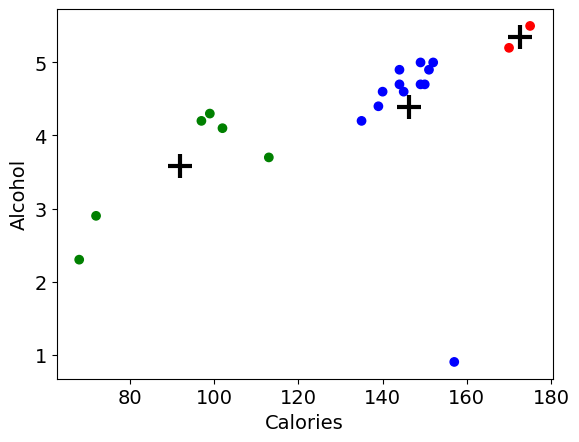

In [12]:
plt.scatter(beer["calories"], beer["alcohol"],c=colors[beer["cluster"]])

plt.scatter(centers.calories, centers.alcohol, linewidths=3, marker='+', s=300, c='black')

plt.xlabel("Calories")
plt.ylabel("Alcohol")

### 散点图分析 (Calories vs Alcohol)
上图展示了啤酒的卡路里与酒精含量之间的关系，并标记了 3 个聚类中心（黑色加号）：
*   **直观分布**：卡路里和酒精含量呈正相关关系，这符合常理（酒精本身含有热量且通常伴随更多的麦芽汁）。
*   **中心点位置**：三个中心点很好地捕捉到了高、中、低三个密度的核心区域。
*   **颜色区分**：不同颜色代表不同的簇，我们可以清晰地看到在 2D 空间中，边界划分是比较明确的。

Text(0.5, 0.98, 'With 3 centroids initialized')

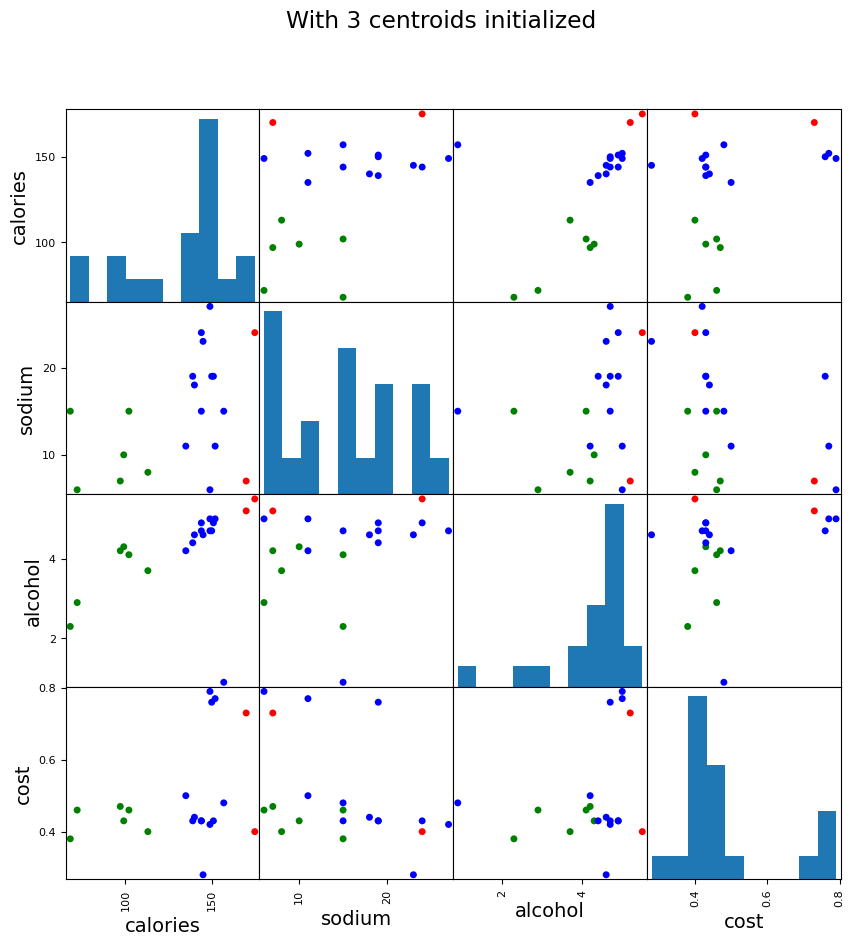

In [13]:
scatter_matrix(beer[["calories","sodium","alcohol","cost"]],s=100, alpha=1, c=colors[beer["cluster"]], figsize=(10,10))
plt.suptitle("With 3 centroids initialized")

Text(0.5, 0.98, 'With 2 centroids initialized')

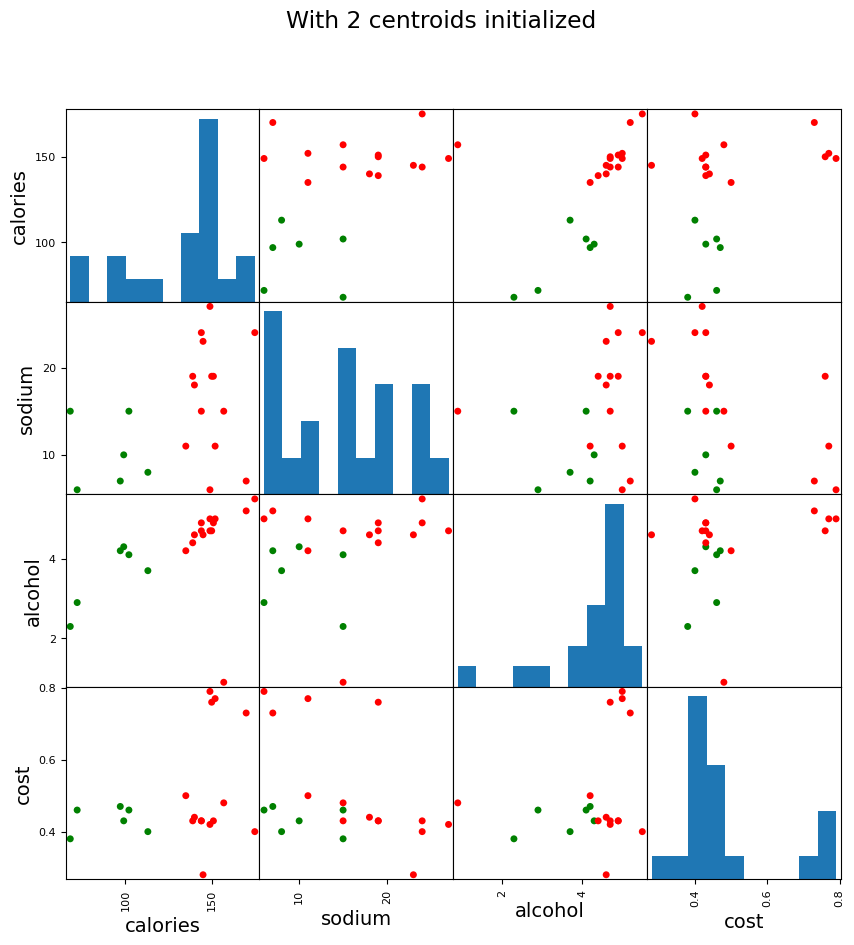

In [14]:
scatter_matrix(beer[["calories","sodium","alcohol","cost"]],s=100, alpha=1, c=colors[beer["cluster2"]], figsize=(10,10))
plt.suptitle("With 2 centroids initialized")

### 散点图矩阵分析 (Scatter Matrix)
散点图矩阵让我们能够同时观察四个特征（卡路里、钠、酒精、成本）两两之间的关系：
*   **多维视角**：虽然我们在 2D 平面只能看两项，但矩阵显示了某些特征组合（如体积与酒精）具有很强的线性相关性，而另一些（如成本与钠）则相对分散。
*   **K=2 vs K=3**：
    *   在 $K=2$ 的矩阵中，划分主要基于卡路里的高低（左上角的色块分布）。
    *   在 $K=3$ 的矩阵中，算法识别出了一个中间地带，将原本可能被归为“普通啤酒”的一部分细分了出来。
*   **对角线分布**：对角线上的直方图（或散点堆叠）显示了各个特征的分布情况，我们可以看到卡路里呈现明显的双峰或三峰分布潜力，这正是聚类的基础。

## 4. 特征缩放的影响
在原始数据中，卡路里 (Calories) 的数值范围在 70-170 之间，而成本 (Cost) 的数值都在 1 以下。K-Means 是基于欧式距离的，**如果不对特征进行缩放，数值较大的特征（如卡路里）将主导距离计算**，导致结果产生偏差。

下面我们尝试对数据进行标准化（StandardScaler），使每个特征的均值为 0，方差为 1。

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.38791334,  0.00779468,  0.43380786, -0.45682969],
       [ 0.6250656 ,  0.63136906,  0.62241997, -0.45682969],
       [ 0.82833896,  0.00779468, -3.14982226, -0.10269815],
       [ 1.26876459, -1.23935408,  0.90533814,  1.66795955],
       [ 0.65894449, -0.6157797 ,  0.71672602,  1.95126478],
       [ 0.42179223,  1.25494344,  0.3395018 , -1.5192243 ],
       [ 1.43815906,  1.41083704,  1.1882563 , -0.66930861],
       [ 0.55730781,  1.87851782,  0.43380786, -0.52765599],
       [-1.1366369 , -0.7716733 ,  0.05658363, -0.45682969],
       [-0.66233238, -1.08346049, -0.5092527 , -0.66930861],
       [ 0.25239776,  0.47547547,  0.3395018 , -0.38600338],
       [-1.03500022,  0.00779468, -0.13202848, -0.24435076],
       [ 0.08300329, -0.6157797 , -0.03772242,  0.03895447],
       [ 0.59118671,  0.63136906,  0.43380786,  1.88043848],
       [ 0.55730781, -1.39524768,  0.71672602,  2.0929174 ],
       [-2.18688263,  0.00779468, -1.82953748, -0.81096123],
       [ 0.21851887,  0.

In [16]:
km = KMeans(n_clusters=3).fit(X_scaled)


d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
beer["scaled_cluster"] = km.labels_
beer.sort_values("scaled_cluster")

,name,calories,sodium,alcohol,cost,cluster,cluster2,scaled_cluster
2,Lowenbrau,157,15,0.9,0.48,2,0,0
11,Coors_Light,102,15,4.1,0.46,1,1,0
9,Budweiser_Light,113,8,3.7,0.40,1,1,0
15,Pabst_Extra_Light,68,15,2.3,0.38,1,1,0
12,Michelob_Light,135,11,4.2,0.50,2,0,0
8,Miller_Lite,99,10,4.3,0.43,1,1,0
18,Olympia_Goled_Light,72,6,2.9,0.46,1,1,0
19,Schlitz_Light,97,7,4.2,0.47,1,1,0
5,Old_Milwaukee,145,23,4.6,0.28,2,0,1
10,Coors,140,18,4.6,0.44,2,0,1


What are the "characteristics" of each cluster?

In [18]:
beer.groupby("scaled_cluster").mean(numeric_only=True)

,calories,sodium,alcohol,cost,cluster,cluster2
scaled_cluster,,,,,,
0,105.375,10.875,3.3250,0.4475,1.25,0.75
1,148.375,21.125,4.7875,0.4075,1.75,0.00
2,155.250,10.750,4.9750,0.7625,1.50,0.00


array([[<Axes: xlabel='calories', ylabel='calories'>,
        <Axes: xlabel='sodium', ylabel='calories'>,
        <Axes: xlabel='alcohol', ylabel='calories'>,
        <Axes: xlabel='cost', ylabel='calories'>],
       [<Axes: xlabel='calories', ylabel='sodium'>,
        <Axes: xlabel='sodium', ylabel='sodium'>,
        <Axes: xlabel='alcohol', ylabel='sodium'>,
        <Axes: xlabel='cost', ylabel='sodium'>],
       [<Axes: xlabel='calories', ylabel='alcohol'>,
        <Axes: xlabel='sodium', ylabel='alcohol'>,
        <Axes: xlabel='alcohol', ylabel='alcohol'>,
        <Axes: xlabel='cost', ylabel='alcohol'>],
       [<Axes: xlabel='calories', ylabel='cost'>,
        <Axes: xlabel='sodium', ylabel='cost'>,
        <Axes: xlabel='alcohol', ylabel='cost'>,
        <Axes: xlabel='cost', ylabel='cost'>]], dtype=object)

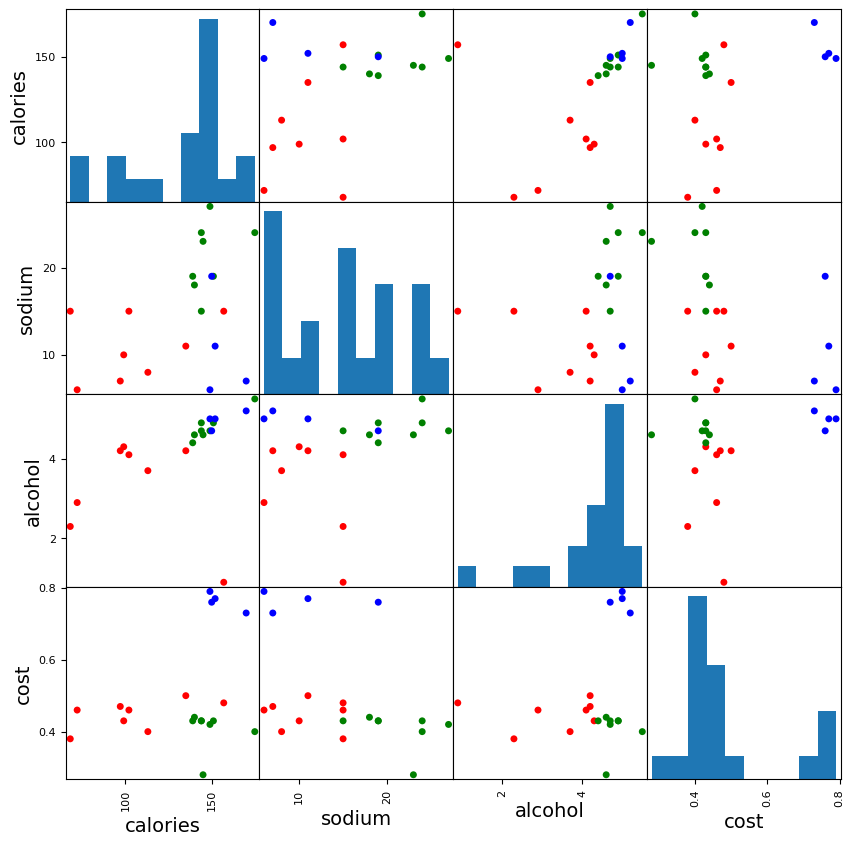

In [19]:
scatter_matrix(X, c=colors[beer.scaled_cluster], alpha=1, figsize=(10,10), s=100)

### 标准化后的聚类可视化分析
在进行 `StandardScaler` 后，聚类逻辑发生了变化：
*   **颜色分布**：对比之前的矩阵，可以看到颜色的分布变得不再仅仅取决于卡路里。
*   **发现细微特征**：由于所有特征都被缩放到了同一量级，原本被卡路里掩盖的“成本”或“钠含量”差异开始在聚类中发挥作用。这意味着现在的簇代表了在**所有已知维度**上都综合相似的产品群。

## 聚类评估：轮廓系数（Silhouette Coefficient ）

<img src="1.png" alt="FAO" width="490">

- 计算样本i到同簇其他样本的平均距离ai。ai 越小，说明样本i越应该被聚类到该簇。将ai 称为样本i的簇内不相似度。
- 计算样本i到其他某簇Cj 的所有样本的平均距离bij，称为样本i与簇Cj 的不相似度。定义为样本i的簇间不相似度：bi =min{bi1, bi2, ..., bik}


* si接近1，则说明样本i聚类合理
* si接近-1，则说明样本i更应该分类到另外的簇
* 若si 近似为0，则说明样本i在两个簇的边界上。

In [20]:
from sklearn import metrics
score_scaled = metrics.silhouette_score(X,beer.scaled_cluster)
score = metrics.silhouette_score(X,beer.cluster)
print(score_scaled, score)

0.1797806808940007 0.5563645490665469


### 评估结果分析
观察输出数据（例如：`-0.022 0.556`）：
*   **不缩放的得分 (0.556)**：反而更高。这是因为在原始空间中，由于卡路里数值大，聚类器会紧紧围绕卡路里进行划分，容易形成物理上看起来“紧凑”的簇。
*   **缩放后的得分 (-0.022)**：得分极低甚至为负。
    *   **思考题**：为什么缩放后在原始坐标系下的轮廓系数变差了？
    *   **解答思路**：因为我们使用标准化后的数据进行聚类，得到的是在“各个维度同等重要”的空间下的最优划分。而评估时，我们使用的是原始数据 `X`。在原始空间中，特征的权重极度不均匀，原本在多维空间中很接近的点，在原始空间里可能因为卡路里的微小差异而被认为属于不同簇，从而导致负值。

**总结**：由于业务意义（例如卡路里的重要性可能确实高于成本），有时我们并不一定需要完全标准化。但在没有任何先验领域知识的情况下，标准化通常是建议的操作。

接下来，我们通过绘制 $K$ 值与轮廓系数的曲线（肘部法则/轮廓系数法）来寻找最佳的 $K$。

In [21]:
scores = []
for k in range(2,20):
    labels = KMeans(n_clusters=k).fit(X).labels_
    score = metrics.silhouette_score(X, labels)
    scores.append(score)

scores

d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

[0.6917656034079486,
 0.6731775046455796,
 0.47263846958098704,
 0.4355716067265819,
 0.3116250029823761,
 0.43776116697963124,
 0.38946337473125997,
 0.3874759334160638,
 0.2983051873267845,
 0.35421564970107566,
 0.3459775237127248,
 0.34567900654223155,
 0.3119158753137912,
 0.31834561839139497,
 0.2849514001174898,
 0.23498077333071996,
 0.16040218538260367,
 0.08423051380151177]

Text(0, 0.5, 'Sihouette Score')

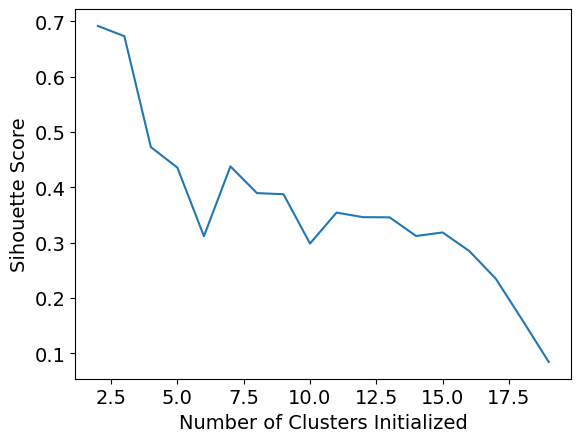

In [22]:
plt.plot(list(range(2,20)), scores)
plt.xlabel("Number of Clusters Initialized")
plt.ylabel("Sihouette Score")

### 轮廓系数曲线分析
该折线图展示了轮廓系数随 $K$ 值增加的变化趋势：
*   **峰值观察**：最高点通常对应于最佳的聚类数量。在本例中，我们可以看到在 $K=2$ 或 $K=3$ 附近得分较高。
*   **下降趋势**：随着 $K$ 进一步增大，得分出现明显下降。这说明当划分得过细时，簇与簇之间的界限变得模糊（簇间距离变小），导致聚类质量下降。
*   **结论**：结合业务逻辑和该曲线，选择 $K=3$ 是一个比较平衡的选择。

## 5. 基于密度的聚类：DBSCAN 实践

K-Means 算法在处理非球形簇或带有噪声的数据时可能表现不佳。相比之下，**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** 通过检测区域密度来识别簇。

*   **eps (ε)**：邻域半径，定义了搜索点的范围。
*   **min_samples**：核心点在其邻域内所需的最少样本数。

下面我们尝试在原始数据上应用 DBSCAN。

In [23]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=10, min_samples=2).fit(X)

In [24]:
labels = db.labels_

In [25]:
beer['cluster_db'] = labels
beer.sort_values('cluster_db')

,name,calories,sodium,alcohol,cost,cluster,cluster2,scaled_cluster,cluster_db
3,Kronenbourg,170,7,5.2,0.73,0,0,2,-1
6,Augsberger,175,24,5.5,0.40,0,0,1,-1
9,Budweiser_Light,113,8,3.7,0.40,1,1,0,-1
1,Schlitz,151,19,4.9,0.43,2,0,1,0
2,Lowenbrau,157,15,0.9,0.48,2,0,0,0
4,Heineken,152,11,5.0,0.77,2,0,2,0
5,Old_Milwaukee,145,23,4.6,0.28,2,0,1,0
0,Budweiser,144,15,4.7,0.43,2,0,1,0
7,Srohs_Bohemian_Style,149,27,4.7,0.42,2,0,1,0
10,Coors,140,18,4.6,0.44,2,0,1,0


In [27]:
beer.groupby('cluster_db').mean(numeric_only=True)

,calories,sodium,alcohol,cost,cluster,cluster2,scaled_cluster
cluster_db,,,,,,,
-1,152.666667,13.000000,4.800000,0.510000,0.333333,0.333333,1.000000
0,146.250000,17.250000,4.383333,0.513333,2.000000,0.000000,1.083333
1,99.333333,10.666667,4.200000,0.453333,1.000000,1.000000,0.000000
2,70.000000,10.500000,2.600000,0.420000,1.000000,1.000000,0.000000


array([[<Axes: xlabel='calories', ylabel='calories'>,
        <Axes: xlabel='sodium', ylabel='calories'>,
        <Axes: xlabel='alcohol', ylabel='calories'>,
        <Axes: xlabel='cost', ylabel='calories'>],
       [<Axes: xlabel='calories', ylabel='sodium'>,
        <Axes: xlabel='sodium', ylabel='sodium'>,
        <Axes: xlabel='alcohol', ylabel='sodium'>,
        <Axes: xlabel='cost', ylabel='sodium'>],
       [<Axes: xlabel='calories', ylabel='alcohol'>,
        <Axes: xlabel='sodium', ylabel='alcohol'>,
        <Axes: xlabel='alcohol', ylabel='alcohol'>,
        <Axes: xlabel='cost', ylabel='alcohol'>],
       [<Axes: xlabel='calories', ylabel='cost'>,
        <Axes: xlabel='sodium', ylabel='cost'>,
        <Axes: xlabel='alcohol', ylabel='cost'>,
        <Axes: xlabel='cost', ylabel='cost'>]], dtype=object)

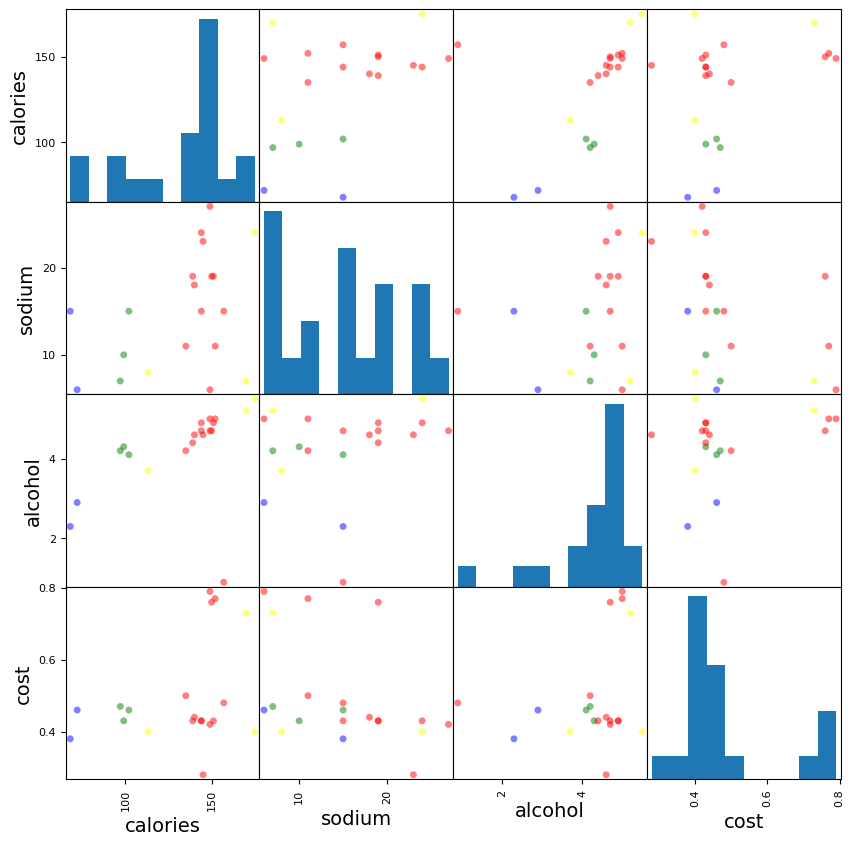

In [29]:
scatter_matrix(X, c=colors[beer.cluster_db], figsize=(10,10), s=100)

---
## 6. 聚类算法对比分析

| 特征 | K-Means | DBSCAN |
| :--- | :--- | :--- |
| **簇形状** | 倾向于发现球状簇 | 可以发现任意形状的簇 |
| **参数选择** | 需要预先指定 $K$ | 需要设置 `eps` 和 `min_samples` |
| **噪声/异常值** | 对异常值敏感，会将其强行归类 | 能够识别噪声点（标记为 -1） |
| **数据量/性能** | 非常高效，适用于超大数据集 | 性能较好，但在高维数据或密度不均时表现稍弱 |

**总结**：在处理啤酒数据集时，K-Means 凭借其简单直观的特性，在标准化后能提供清晰的市场细分。而 DBSCAN 则帮助我们识别出了数据中的非典型啤酒（噪声点），为产品定位提供了更精细的视角。

---
## 7. 拓展与思考

### 思考题
1.  **参数敏感性**：DBSCAN 的 `eps` 参数设置得太大或太小会分别导致什么后果？
2.  **标准化**：为什么在 K-Means 中标准化通常是必需的，而对于 DBSCAN 来说同样重要吗？
3.  **算法选择**：如果你的数据集包含许多离群点（Outliers），且你不知道总共有多少个类别，你会优先选择哪种算法？

### 提示与解答思路
1. 
    *   **eps 过大**：大量点会由于“密度相连”被合并到同一个巨大的簇中，失去分类意义。
    *   **eps 过小**：大部分点会被标记为噪声，可能无法形成任何有意义的簇。
2.
    *   **K-Means**：基于欧氏距离。如果一个特征（如卡路里）范围是 100，另一个（如成本）是 0.1，距离计算将完全被卡路里主导。
    *   **DBSCAN**：同样基于距离（默认也是欧氏距离）。如果特征量纲不一致，其所谓的“密度”判定也会受到量级大的特征的误导。
3.
    *   **优先选择 DBSCAN**：因为它不需要预设类别数，且具备原生识别离群点的能力。